In [1]:
import numpy as np
from numpy.fft import fft, ifft
import matplotlib.pyplot as plt
from scipy.sparse import diags, kron
from scipy.sparse.linalg import expm_multiply

In [2]:
# a single point is arranged along the last axis [i_1,i_2,...,i_d,:]
def delta_multivar(x, omega):
    # computes multivariate delta function on each point
    assert omega > 0
    return np.prod(delta_1d(x, omega), axis=-1)
def delta_1d(x, omega):
    assert omega > 0
    return (np.abs(x) <= omega) *  beta_2(x / omega) / omega
def beta(x):
    return 1 - np.abs(x)
def beta_2(x):
    return (1 + np.cos(np.pi * x)) / 2
def beta_3(x):
    return 2

## scalar nonlinear hyperbolic pde 

### burger's equation

In [46]:
M = 2
N = 1024
N_p = N
h = 1/N
m = 3
omega = (m * h) ** (1/3)

In [47]:
x, p = np.meshgrid(np.linspace(0, 1, N), np.linspace(0, 1, N_p), indexing='ij')

In [48]:
mu = [0.3, 0.7]
sigma = [0.08, 0.05]
# u_0 = np.zeros_like(x)
# u_0 = u_0[np.newaxis,:]
# u_0[0] = np.exp(-0.5 * ((x - mu) / sigma) ** 2) / 1.1 #/ (sigma * np.sqrt(2 * np.pi))

In [49]:
u_0 = np.stack(
    [np.exp(-0.5 * ((x - mu[i]) / sigma[i]) ** 2) / 1.1 for i in range(M)]
    , axis=0)

assert u_0.shape[0] == M

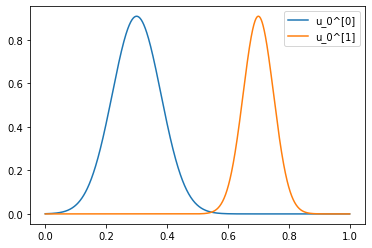

In [50]:
for i in range(M):
    plt.plot(x[:,0], u_0[i,:,0], label=f"u_0^[{i}]")

plt.legend()
plt.show()

In [51]:
psi_0 = np.zeros_like(x)

for i in range(M):
    psi_0 += delta_1d(p - u_0[i], omega)

psi_0 /= M

In [52]:
discrete_gradient = diags([-np.ones(N-1), np.zeros(N), np.ones(N-1)], offsets=[-1,0,1])

In [53]:
discrete_gradient = discrete_gradient.tolil()

In [54]:
discrete_gradient[0,N-1] = -1
discrete_gradient[N-1,0] = 1

discrete_gradient /= 2 * h

In [55]:
discrete_gradient_vec = np.zeros(N)

# second order central differences (flipped)
discrete_gradient_vec[1] = -1
discrete_gradient_vec[-1] = 1

discrete_gradient_vec /= 2 * h

evals = np.fft.fft(discrete_gradient_vec)

In [56]:
T = 0.5
N_t = 5 # time points

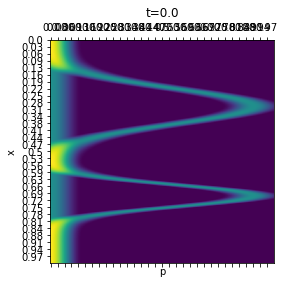

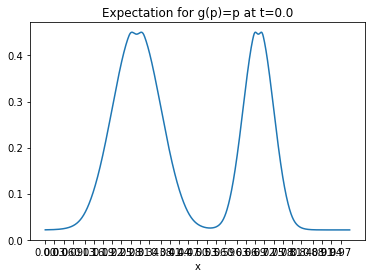

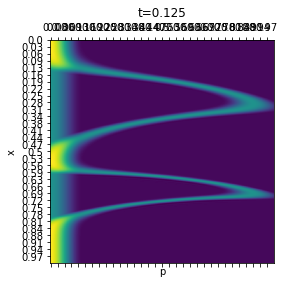

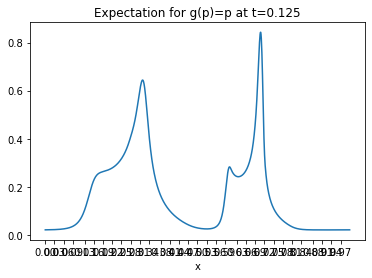

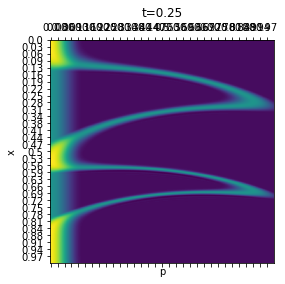

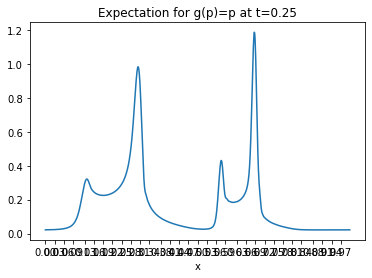

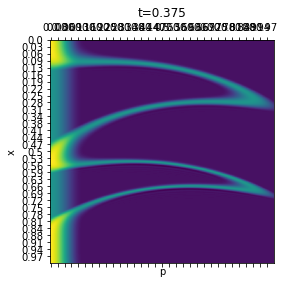

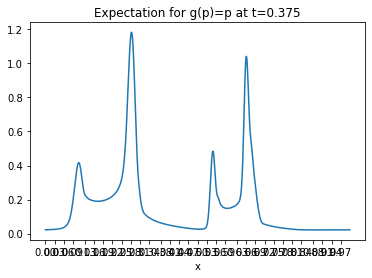

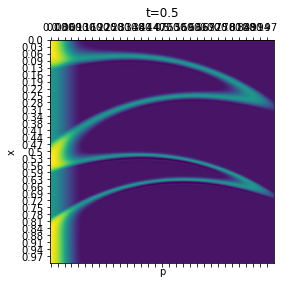

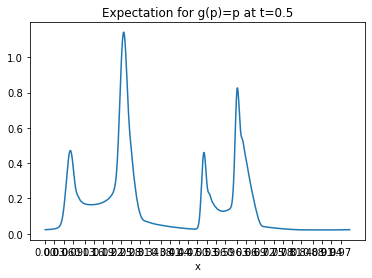

In [58]:
for t in np.linspace(0, T, N_t):
    psi = np.zeros_like(psi_0)
    for i,p_val in enumerate(np.linspace(0, 1, N_p)):

        psi[:,i] = ifft(np.exp(-(p_val ** 2 - p_val) * t * evals) * fft(psi_0[:,i])).real
        # psi[:,i] = expm_multiply(-p_val * discrete_gradient * t, psi_0[:,i])
    plt.matshow(psi)
    plt.title(f"t={t}")
    plt.ylabel("x")
    plt.yticks(np.arange(N, step=32), np.round(x[::32,0], decimals=2))
    plt.xlabel("p")
    plt.xticks(np.arange(N_p, step=32), np.round(p[0,::32], decimals=2))
    plt.savefig(f"level_set_{t : 0.3f}.png", dpi=100, facecolor="white")
    plt.show()

    exp_g = np.average(p * psi, axis=1)
    plt.plot(x[:,0], exp_g)
    plt.title(f"Expectation for g(p)=p at t={t}")
    plt.xlabel("x")
    plt.xticks(np.round(x[::32,0], decimals=2))
    plt.show()

In [213]:
# g is a function of p (density, momentum, or energy corresponding to the 0th, 1st, and 2nd moment)
# g = p